Ejemplo PID

In [8]:
# Import the packages needed for the examples included in this notebook
import numpy as np
import matplotlib.pyplot as plt
import control as ct

Definición del sistema

In [9]:
T = 0.1
num = [5]
den = [1.0000, -1.6000, 0.6300]

sys = ct.tf(num, den, T)
print(sys)

<TransferFunction>: sys[13]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']
dt = 0.1

          5
  ------------------
  z^2 - 1.6 z + 0.63


Simulamos el sistema en BA

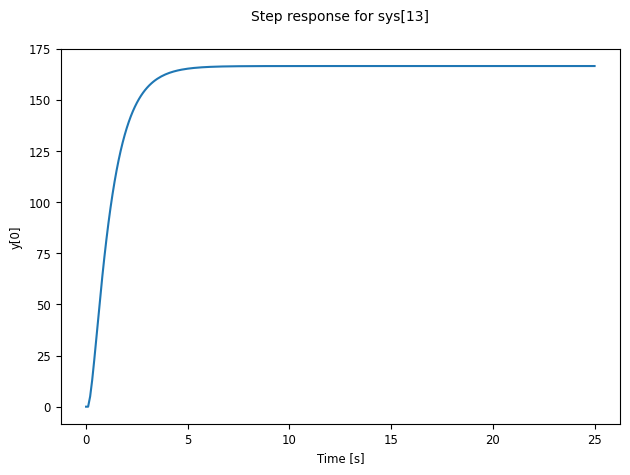

In [10]:
sal = ct.step_response(sys).plot()

Añadimos el controlador

In [13]:
num_cont = [0.04000, -0.05112, 0.01168]
den_cont = [1, -1, 0]

sys_cont = ct.tf(num_cont, den_cont, T)
print(sys_cont)

<TransferFunction>: sys[20]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']
dt = 0.1

  0.04 z^2 - 0.05112 z + 0.01168
  ------------------------------
             z^2 - z


Obtenemos la realimentación

In [14]:
sys_serie = ct.series(sys, sys_cont)
print(sys_serie)
#sal_serie = ct.step_response(sys_serie).plot()
sal_loop_cont = ct.feedback(sys_serie, 1, sign = -1)
print(sal_loop_cont)

<TransferFunction>: sys[21]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']
dt = 0.1

     0.2 z^2 - 0.2556 z + 0.0584
  ---------------------------------
  z^4 - 2.6 z^3 + 2.23 z^2 - 0.63 z
<TransferFunction>: sys[23]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']
dt = 0.1

          0.2 z^2 - 0.2556 z + 0.0584
  --------------------------------------------
  z^4 - 2.6 z^3 + 2.43 z^2 - 0.8856 z + 0.0584


Obtenemos la respuesta step

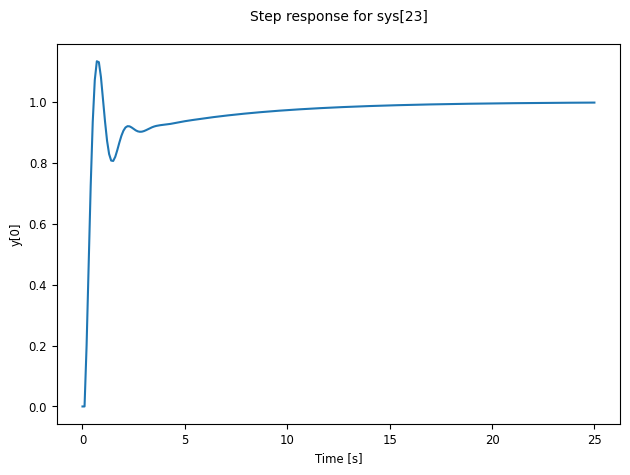

In [15]:
sal_loop = ct.step_response(sal_loop_cont).plot()